# SMART CART: 1인 가구를 위한 카메라 기반 장바구니

KOSIS·KREI 데이터로 서비스 필요성을 확인하고, YOLO 상품 인식·SQLite·PySide6 GUI를 연결한 DNN 미니프로젝트입니다.

## 분석 준비

아래 셀은 분석 데이터와 그래프 도구를 불러옵니다. KREI 비율은 표본 가중치 HHFWT를 적용해 계산합니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from zipfile import ZipFile
from io import BytesIO
from pathlib import Path
import re

font_path = Path(r'C:\Windows\Fonts\malgun.ttf')
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

data_dir = Path('datas')
output_dir = Path('outputs')
output_dir.mkdir(exist_ok=True)
kos_is_zip = data_dir / '1인가구(2020~2025).zip'
krei_xlsx = data_dir / '(data_가중) 2025 식품소비행태조사_주구입자.xlsx'

## 분석 질문 1. 스마트카트의 주요 타깃인 1인 가구는 실제로 증가하고 있는가?

사용 데이터/변수: KOSIS 2020~2025년 1인 가구 수  
분석 방법: 연도별 전국 1인 가구 수와 증가율 계산  
서비스 연결: 1인 가구 증가 → 스마트카트 주요 타깃 확대

In [2]:
result = []

with ZipFile(kos_is_zip) as outer_zip:
    for file_name in outer_zip.namelist():
        if file_name.endswith('.zip'):
            year = int(re.search(r'(20\d{2})\.zip$', file_name).group(1))
            inner_file = BytesIO(outer_zip.read(file_name))

            with ZipFile(inner_file) as inner_zip:
                csv_name = inner_zip.namelist()[0]
                year_df = pd.read_csv(inner_zip.open(csv_name), encoding='cp949', skiprows=2)
                households = year_df['1인가구'].iloc[0]
                households = float(str(households).replace(',', '').replace("'", ''))
                result.append([year, households])

In [3]:
trend_df = pd.DataFrame(result, columns=['year', 'households'])
trend_df = trend_df.sort_values('year')
growth_rate = (trend_df['households'].iloc[-1] / trend_df['households'].iloc[0] - 1) * 100
print(f'2020~2025년 1인 가구 증가율: {growth_rate:.1f}%')
trend_df

2020~2025년 1인 가구 증가율: 24.1%


,year,households
0,2020,6643354.0
1,2021,7165788.0
2,2022,7502350.0
3,2023,7829035.0
4,2024,8044948.0
5,2025,8244308.0


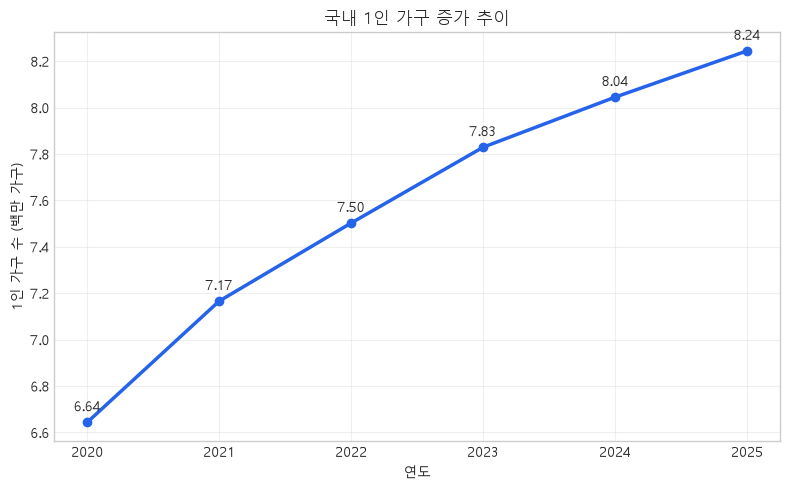

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = font_manager.FontProperties(fname=font_path).get_name()
plt.figure(figsize=(8, 5))
plt.plot(trend_df['year'], trend_df['households'] / 1000000, marker='o', linewidth=2.5, color='#2563eb')
plt.title('국내 1인 가구 증가 추이')
plt.xlabel('연도')
plt.ylabel('1인 가구 수 (백만 가구)')
plt.xticks(trend_df['year'])
for year, value in zip(trend_df['year'], trend_df['households'] / 1000000):
    plt.annotate(f'{value:.2f}', (year, value), xytext=(0, 8), textcoords='offset points', ha='center')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / '01_single_household_trend.png', dpi=180)
plt.show()

**해석:** 이 셀의 실제 계산 결과로 1인 가구 시장의 규모와 증가 추세를 확인한다.

## KREI 식품소비행태조사 데이터

이후 질문은 KREI 2025 식품소비행태조사 마이크로데이터를 사용한다. SQ3N(가구원 수), A2_1(식품 구매처), A22(물가 체감), F22_1(간편식 선택 이유), HHFWT(가중치)를 사용한다.

In [5]:
df = pd.read_excel(krei_xlsx, sheet_name='Numeric')
print('데이터 크기:', df.shape)
df[['SQ3N', 'A2_1', 'A22', 'F22_1', 'HHFWT']].head()

데이터 크기: (3237, 1585)


,SQ3N,A2_1,A22,F22_1,HHFWT
0,1,3,105,1.0,8551.481610
1,3,1,125,1.0,2843.486969
2,4,1,120,2.0,5083.456872
3,4,4,130,1.0,6492.502392
4,3,3,120,2.0,2303.452123


## 분석 질문 2. 1인 가구가 오프라인 마트를 충분히 이용하는가?

사용 데이터/변수: SQ3N == 1, A2_1, HHFWT  
분석 방법: 구매처별 가중 비율 계산  
서비스 연결: 오프라인 식료품 구매 → 카트 기반 서비스 환경의 타당성

In [6]:
single_df = df[df['SQ3N'] == 1].copy()

place_map = {1:'동네 슈퍼/식자재마트', 2:'기업형 슈퍼마켓', 3:'대형마트', 4:'전통시장',
             5:'백화점', 6:'친환경 식품 전문점', 7:'온라인 쇼핑몰', 8:'TV 홈쇼핑',
             9:'편의점', 10:'로컬푸드 마켓', 11:'반찬가게', 12:'기타'}

place_data = single_df[['A2_1', 'HHFWT']].dropna()
place_ratio = place_data.groupby('A2_1')['HHFWT'].sum()
place_ratio = place_ratio / place_data['HHFWT'].sum() * 100
place_ratio.index = place_ratio.index.map(place_map)
place_ratio = place_ratio.sort_values(ascending=False)
place_ratio.head()

A2_1
동네 슈퍼/식자재마트    36.646793
온라인 쇼핑몰        19.652677
대형마트           17.914996
전통시장           14.742761
기업형 슈퍼마켓        9.682057
Name: HHFWT, dtype: float64

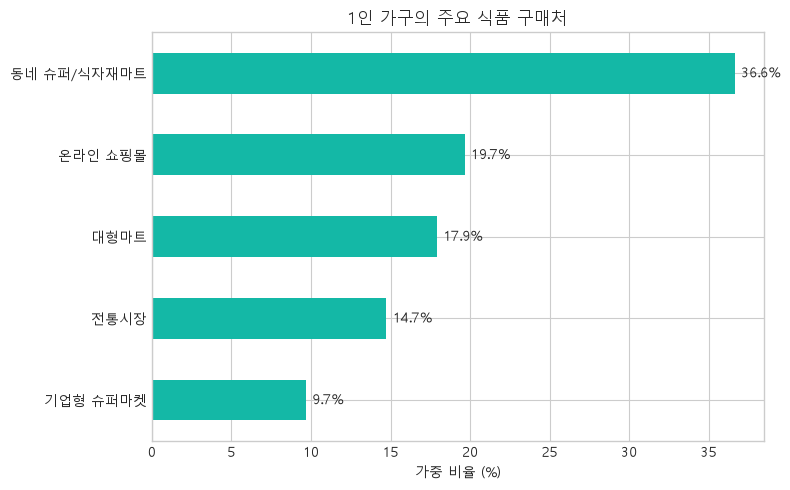

In [7]:
top5 = place_ratio.head(5).sort_values()
top5.plot(kind='barh', figsize=(8, 5), color='#14b8a6')
for i, value in enumerate(top5.values):
    plt.text(value + 0.4, i, f'{value:.1f}%', va='center')
plt.title('1인 가구의 주요 식품 구매처')
plt.xlabel('가중 비율 (%)')
plt.ylabel('')
plt.tight_layout()
plt.savefig(output_dir / '02_food_purchase_places.png', dpi=180)
plt.show()

**해석:** 가장 높은 구매처 비율을 실제 계산 결과로 확인해 오프라인 스마트카트의 사용 환경을 검증한다.

## 분석 질문 3. 소비자가 식품 가격 부담을 크게 느끼고 있는가?

사용 데이터/변수: A22, HHFWT  
분석 방법: A22 > 100 응답의 가중 비율 계산  
서비스 연결: 가격 부담 → 상품 가격 조회와 실시간 장바구니 총액

In [8]:
price_data = df[['A22', 'HHFWT']].dropna()
increased_weight = price_data[price_data['A22'] > 100]['HHFWT'].sum()
total_weight = price_data['HHFWT'].sum()
increased = increased_weight / total_weight * 100
print(f'식품 물가 상승 체감 비율: {increased:.1f}%')

price_result = pd.Series({'물가 상승 체감': increased, '동일/하락 체감': 100 - increased})

식품 물가 상승 체감 비율: 94.1%


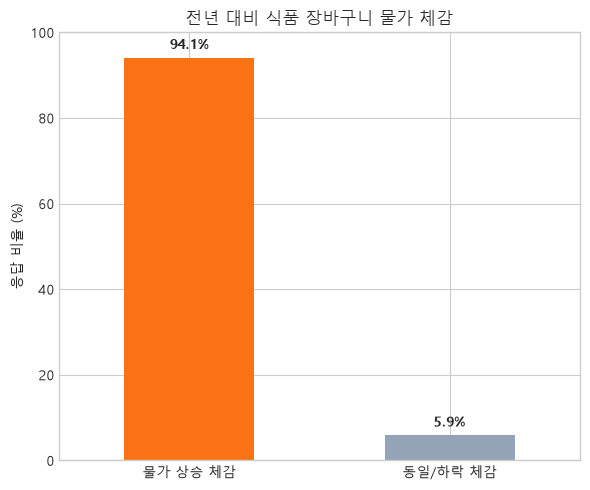

In [9]:
price_result.plot(kind='bar', figsize=(6, 5), color=['#f97316', '#94a3b8'])
for bar, value in zip(plt.gca().patches, price_result.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 2, f'{value:.1f}%', ha='center', fontweight='bold')
plt.title('전년 대비 식품 장바구니 물가 체감')
plt.ylabel('응답 비율 (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(output_dir / '03_price_burden.png', dpi=180)
plt.show()

**해석:** 물가 상승 체감 비율을 실제 계산 결과로 확인한다. 가격과 총액을 즉시 보여줄 필요가 있다.

## 분석 질문 4. 1인 가구가 식생활에서 편리성과 비용을 중요하게 생각하는가?

사용 데이터/변수: SQ3N == 1, F22_1, HHFWT  
분석 방법: 선택 이유를 편리함·비용 절감 등으로 묶어 가중 비율 계산  
서비스 연결: 편리성·비용 중시 → 보유 식재료 기반 레시피 추천

In [10]:
hmr_map = {1:'비용 절감', 2:'맛·다양성', 3:'편리함', 4:'편리함', 5:'편리함',
           6:'맛·다양성', 7:'외식비 감소', 8:'편리함', 9:'영양', 10:'기타'}

hmr_data = single_df[['F22_1', 'HHFWT']].dropna().copy()
hmr_data['선택 이유'] = hmr_data['F22_1'].map(hmr_map)

hmr_ratio = hmr_data.groupby('선택 이유')['HHFWT'].sum()
hmr_ratio = hmr_ratio / hmr_data['HHFWT'].sum() * 100
hmr_ratio = hmr_ratio.sort_values(ascending=False)
hmr_ratio

선택 이유
편리함       42.315610
비용 절감     33.889277
맛·다양성     23.029607
외식비 감소     0.554353
영양         0.211154
Name: HHFWT, dtype: float64

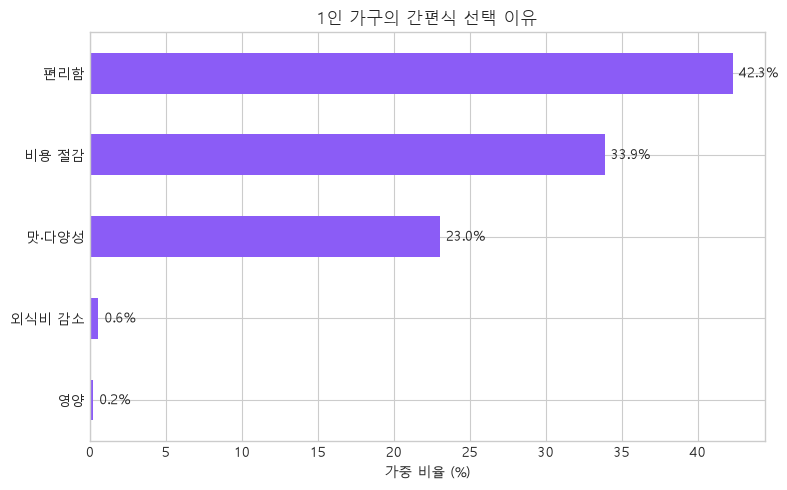

In [11]:
hmr_ratio.sort_values().plot(kind='barh', figsize=(8, 5), color='#8b5cf6')
for i, value in enumerate(hmr_ratio.sort_values().values):
    plt.text(value + 0.4, i, f'{value:.1f}%', va='center')
plt.title('1인 가구의 간편식 선택 이유')
plt.xlabel('가중 비율 (%)')
plt.ylabel('')
plt.tight_layout()
plt.savefig(output_dir / '04_hmr_reasons.png', dpi=180)
plt.show()

**해석:** 상위 선택 이유를 실제 계산 결과로 확인한다. 보유 재료로 메뉴를 추천하면 편리성과 비용 절감에 연결된다.

## 서비스 기능 도출

| 데이터에서 확인한 문제 | 서비스 요구사항 | 구현 기능 |
| --- | --- | --- |
| 1인 가구 증가 | 주요 타깃 지원 | 1인 가구 식재료 중심 데모 |
| 오프라인 식료품 구매 | 매장 내 즉시 사용 | 카메라 상품 인식 |
| 식품 물가 부담 | 지출 확인 | 상품 가격·실시간 총액 |
| 편리성·비용 중시 | 보유 재료 활용 | DB 기반 레시피 추천 |

## 데이터 분석 최종 요약

아래 표는 앞선 셀에서 실제 계산된 변수를 모아 서비스 기능과 연결한다.

In [12]:
summary_df = pd.DataFrame([
['1인 가구 증가', f'{growth_rate:.1f}% 증가 (2020~2025)', '주요 타깃'],
['식료품 구매처', f'{place_ratio.index[0]} {place_ratio.iloc[0]:.1f}%', '오프라인 스마트카트'],
['장바구니 물가', f'상승 체감 {increased:.1f}%', '실시간 가격/총액'],
['간편식 선택 이유', f'{hmr_ratio.index[0]} {hmr_ratio.iloc[0]:.1f}%', '레시피 추천'],
], columns=['분석', '핵심 결과', '서비스 기능'])
display(summary_df)

,분석,핵심 결과,서비스 기능
0,1인 가구 증가,24.1% 증가 (2020~2025),주요 타깃
1,식료품 구매처,동네 슈퍼/식자재마트 36.6%,오프라인 스마트카트
2,장바구니 물가,상승 체감 94.1%,실시간 가격/총액
3,간편식 선택 이유,편리함 42.3%,레시피 추천


데이터  
↓  
문제 발견  
↓  
서비스 요구사항 도출

# YOLO Object Detection 모델

카메라 영상에서 상품을 찾아 class, confidence, x, y, width, height를 반환한다. class는 SQLite 상품 키로 사용한다.

## Dataset
서비스 DB에서 관리하는 상품 클래스는 apple, bread, carrot, egg, galic, l_onion, onion, raw_pork, shrimp, sliced_ham의 10개다. 원본 이미지·주석 수와 Train/Validation/Test 구성은 파일이 있을 때만 아래 셀에서 확인한다.

In [13]:
from smart_cart.database import PRODUCTS
service_classes = [name for name, _, _ in PRODUCTS]
raw_image_count = sum(1 for x in Path('images').rglob('*') if x.suffix.lower() in {'.jpg', '.jpeg', '.png'})
print('서비스 상품 클래스 수:', len(service_classes))
print('클래스:', ', '.join(service_classes))
print('프로젝트 images 폴더의 원본 이미지 수:', raw_image_count)
dataset_dir = Path('model_evaluation/ozm-4-yolov8')
if dataset_dir.exists():
    for split in ['train', 'valid', 'test']:
        print(f'{split}: 이미지 {len(list((dataset_dir / split / "images").glob("*")))}장, 주석 {len(list((dataset_dir / split / "labels").glob("*.txt")))}개')
else:
    print('Train / Validation / Test 및 주석 수: 로컬 평가 데이터 파일이 없어 표시하지 않음')

서비스 상품 클래스 수: 10
클래스: galic, apple, l_onion, raw_pork, onion, sliced_ham, carrot, egg, shrimp, bread
프로젝트 images 폴더의 원본 이미지 수: 0
Train / Validation / Test 및 주석 수: 로컬 평가 데이터 파일이 없어 표시하지 않음


## Model과 Evaluation

현재 사용 모델 ID는 sang-rqj4u/ozm-4-yolov8n-t1이며 환경변수 ROBOFLOW_MODEL_ID로 변경할 수 있다. ID 구조는 workspace/project-version-model이다. OpenCV 카메라 프레임을 Hosted Inference로 바로 전송할 수 있어 소규모 데모에 적합하다.

저장된 PR Curve는 evaluate_pr_curve.py가 OZM v4 테스트 이미지 93장을 IoU 0.5 기준으로 평가해 만든 실제 결과다. 에폭별 Loss는 Hosted Inference API가 제공하지 않으므로 임의로 표시하지 않는다. 클래스별 편차는 데이터 수·촬영 환경·클래스 다양성에 따라 생길 수 있다.

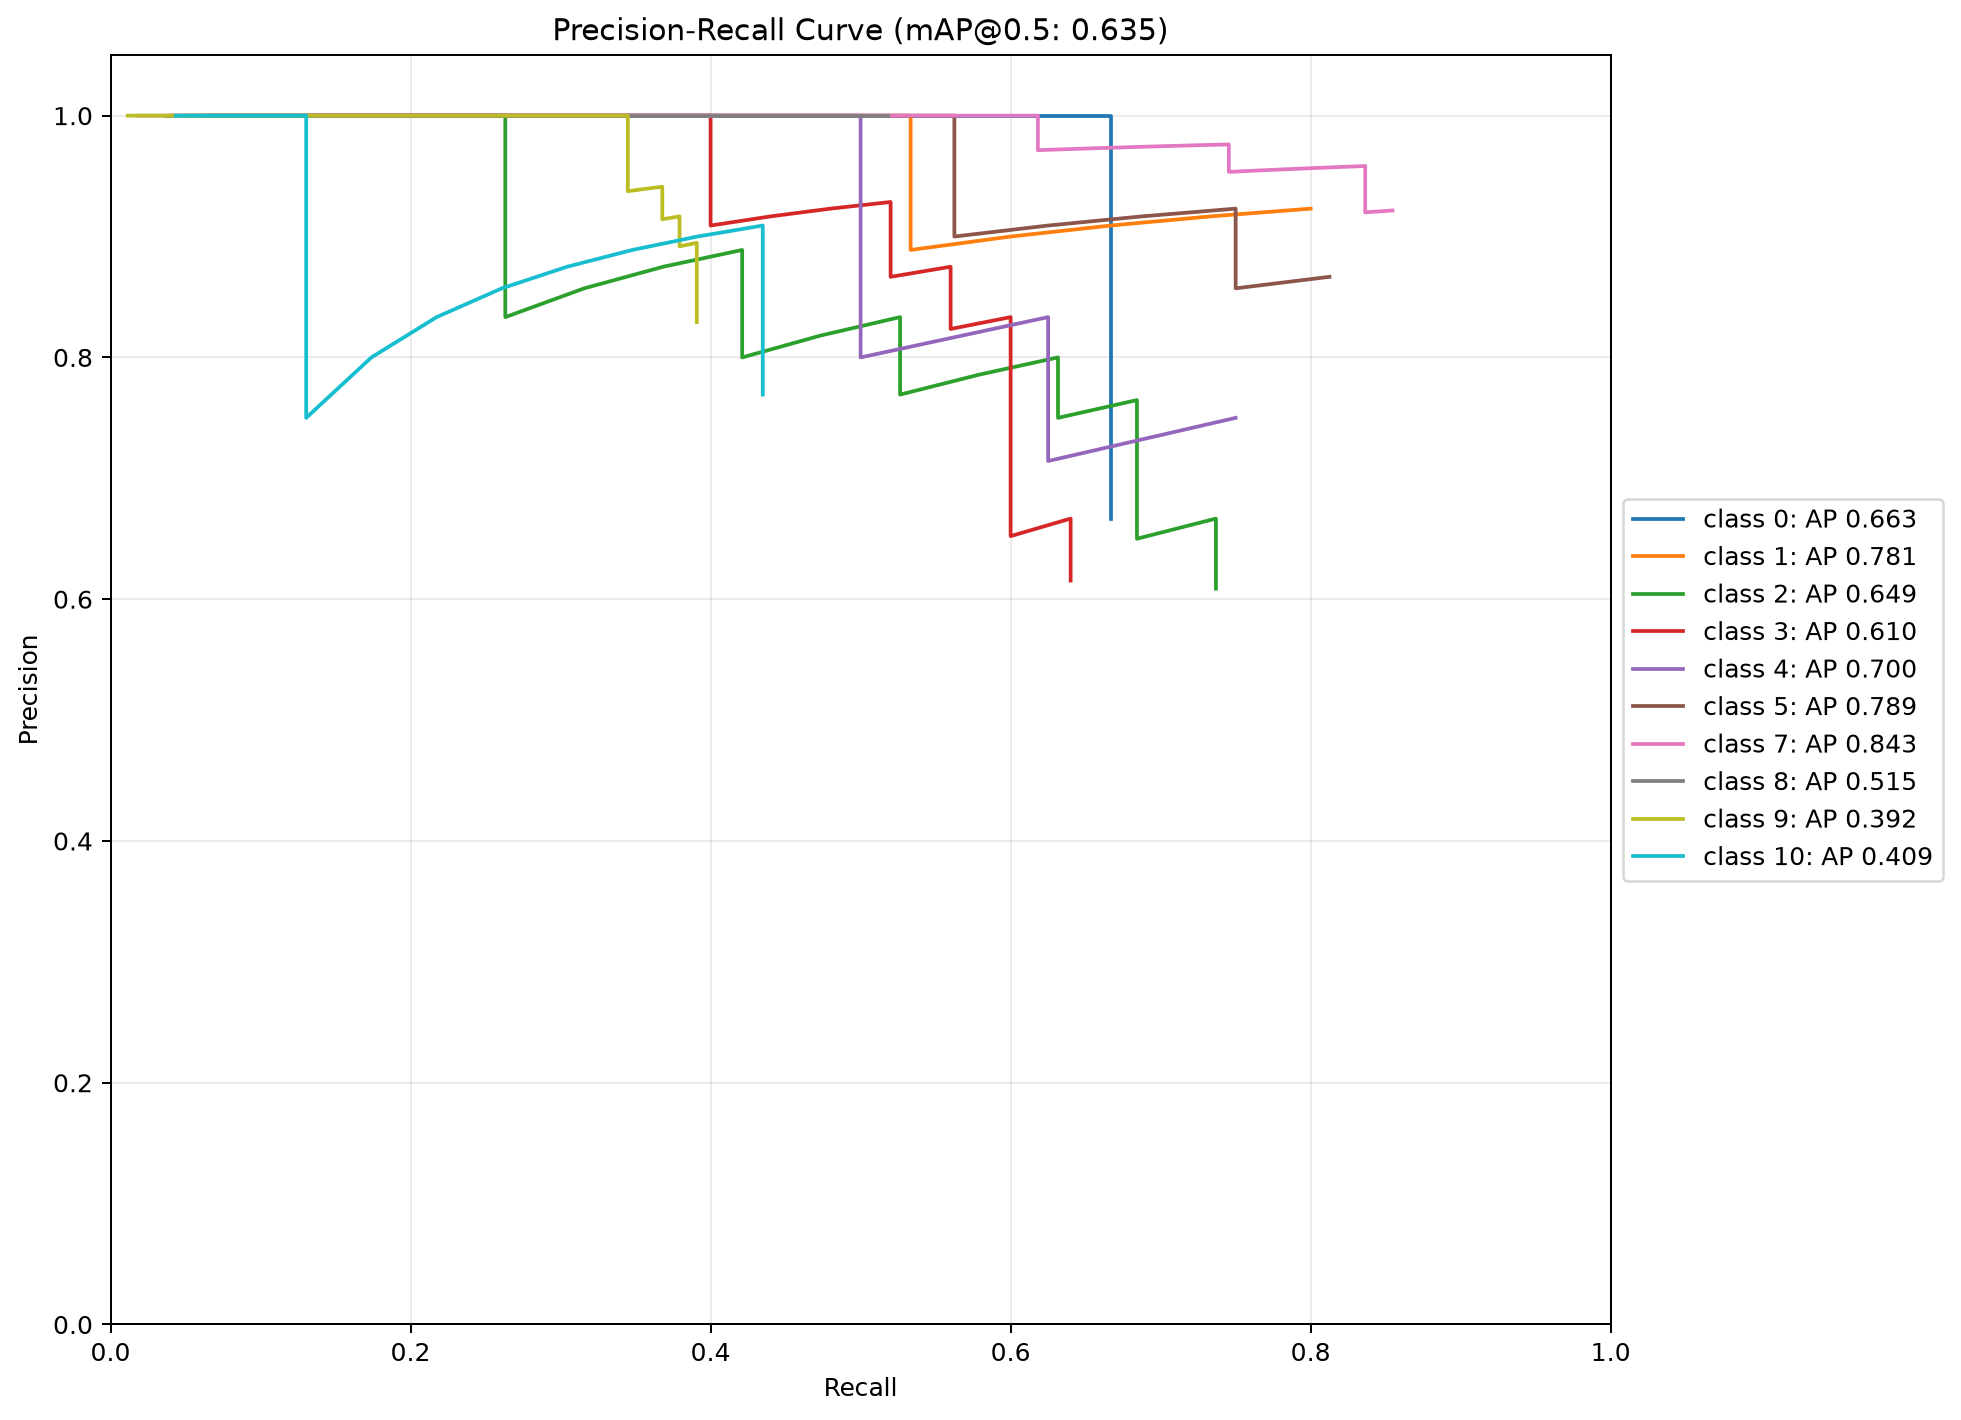

In [14]:
from IPython.display import Image, display
pr_curve_path = Path('outputs/roboflow_pr_curve.png')
if pr_curve_path.exists():
    display(Image(filename=str(pr_curve_path)))
else:
    print('PR Curve 파일이 없습니다. 필요하면 uv run python evaluate_pr_curve.py를 실행하세요.')

# SQLite Database

GUI와 동일한 SmartCartDatabase를 사용한다.

- products: YOLO class_name, 상품명, 가격
- recipes: 메뉴명, 설명
- recipe_ingredients: Recipe와 Product의 N:M 관계

products
↓
recipe_ingredients
↑
recipes

## DB 데모 1. YOLO class 결과 → 상품명과 가격

예시 YOLO class를 products에서 parameter binding으로 조회한다.

In [15]:
from smart_cart.database import SmartCartDatabase
detected_classes = ['onion', 'egg', 'l_onion']
db = SmartCartDatabase('smart_cart_demo.db')
cart_items = []
for class_name in detected_classes:
    product = db.get_product(class_name)
    if product:
        _, product_name, price = product
        cart_items.append({'class_name': class_name, '상품명': product_name, '가격(원)': price})
cart_df = pd.DataFrame(cart_items)
display(cart_df)

,class_name,상품명,가격(원)
0,onion,양파,2000
1,egg,계란,4000
2,l_onion,대파,1800


## DB 데모 2. 장바구니 총액

동일 class가 재인식되면 GUI에서는 수량을 증가시킨다. 이 예시는 한 번씩 인식된 상품의 총액이다.

In [16]:
cart_total = cart_df['가격(원)'].sum()
print(f'장바구니 총액: {cart_total:,}원')

장바구니 총액: 7,800원


## DB 데모 3. DB 기반 레시피 추천

get_recipes는 recipes + recipe_ingredients + products를 JOIN하고, 보유 class와 비교해 충족 수·충족률을 계산한다. 100% 메뉴를 먼저, 다음은 충족률 순으로 반환한다.

In [17]:
available_classes = set(detected_classes)
recipes = db.get_recipes(available_classes)
rows = []
for recipe in recipes:
    missing = [name for class_name, name in zip(recipe['classes'], recipe['ingredients']) if class_name not in available_classes]
    rows.append({'메뉴': recipe['name'], '재료 충족': f"{recipe['owned_count']} / {recipe['needed_count']}", '충족률': f"{recipe['match_rate']:.0f}%", '부족한 재료': ', '.join(missing) if missing else '없음'})
display(pd.DataFrame(rows))
db.close()

,메뉴,재료 충족,충족률,부족한 재료
0,계란찜,2 / 2,100%,없음
1,해물파전,2 / 3,67%,새우
2,대파새우전,2 / 3,67%,새우
3,새우볶음밥,3 / 5,60%,"당근, 새우"


# Roboflow Hosted Inference

API Key는 프로젝트 최상위 .env에서만 읽고 절대 출력하지 않는다.

Camera Frame → InferenceHTTPClient → Roboflow Hosted Inference → predictions
class, confidence, x, y, width, height

설치된 inference_sdk가 지원하는 Authorization header 방식을 사용한다.

In [18]:
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path=Path('.env'), override=True)
rf_api_key = os.getenv('RF_API_KEY') or os.getenv('ROBOFLOW_API_KEY')
model_id = os.getenv('ROBOFLOW_MODEL_ID', 'sang-rqj4u/ozm-7-yolov8n-t1')
print('API Key 로드 여부:', bool(rf_api_key))
print('모델 ID:', model_id)

API Key 로드 여부: True
모델 ID: sang-rqj4u/ozm-7-yolov8n-t1


## Inference 클라이언트

이 셀은 카메라 프레임을 Hosted 모델에 전송할 클라이언트를 만든다. 실제 검출은 CameraWorker가 수행한다.

In [19]:
from inference_sdk import InferenceConfiguration, InferenceHTTPClient
CLIENT = InferenceHTTPClient(api_url='https://detect.roboflow.com', api_key=rf_api_key)
CLIENT.configure(InferenceConfiguration(api_key_transport='header'))
print('Authorization header 방식의 Inference 클라이언트를 만들었습니다.')

Authorization header 방식의 Inference 클라이언트를 만들었습니다.


c:\Users\Admin\Documents\dev_win\smart_cart_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Smart Cart 전체 시스템

Camera
↓
OpenCV
↓
CameraWorker (QThread)
↓
Roboflow Hosted Inference
↓
YOLO Prediction (class, confidence, bbox)
↓
SQLite products (class_name → 상품명 / 가격)
↓
Cart Logic (상품 / 수량 / 합계)
↓
SQLite Recipe (보유 재료 → 추천 메뉴)
↓
PySide6 GUI

GUI: Camera Preview · Bounding Box · 최근 인식 상품 · Confidence · 장바구니 · 상품 가격 · 수량 · 총 구매금액 · 추천 레시피

## PySide6 GUI 실행 준비

- CameraWorker(QThread): 카메라 frame 획득, 일정 간격의 Roboflow 추론, Bounding Box drawing, frame_ready·detections_ready Signal 전송
- SmartCartWindow: Signal 수신, YOLO class의 DB 상품 조회, 3초 안정 인식 후 장바구니 등록, 총액 계산, DB 레시피 추천, 화면 갱신

네트워크 기반 추론과 카메라 처리를 GUI 이벤트 루프와 분리해 화면이 멈추는 것을 방지한다. 실제 구현은 smart_cart.roboflow_detector, smart_cart.main을 재사용한다.

In [20]:
import sys
print('다음 셀을 실행하면 SMART CART PySide6 창이 열립니다.')

다음 셀을 실행하면 SMART CART PySide6 창이 열립니다.


In [22]:
!{sys.executable} -m smart_cart.main

### Smart Cart 동작 시나리오

1. 카메라에서 상품 촬영
2. YOLO가 상품 검출
3. class/confidence 반환
4. SQLite에서 상품명/가격 조회
5. 장바구니 등록
6. 상품별 가격 및 전체 합계 갱신
7. 장바구니 class 목록 생성
8. SQLite 레시피 DB 조회
9. 재료 충족도가 높은 요리 추천
10. PySide6 화면에 결과 표시

이 흐름이 이번 프로젝트의 핵심 End-to-End Pipeline이다.

# 프로젝트 최종 결과

## 문제
1인 가구 증가, 오프라인 식품 구매, 물가 부담, 편리성·비용 중시를 데이터 분석으로 확인한다.

## 해결
YOLO가 카메라에서 식품을 인식하고, SQLite가 상품 가격과 레시피를 연결하며, PySide6가 장바구니 결과를 즉시 보여준다.

## 구현 결과
Camera → YOLO → DB → Cart → Recipe → GUI

## 한계
- 일부 객체 클래스의 검출 성능 편차
- Roboflow Hosted Inference의 네트워크 의존성
- 상품 가격은 실제 마트 연동이 아닌 데모 데이터
- 레시피 데이터 규모가 작음
- 실제 마트 카트 환경 데이터가 더 필요함

## 향후 개선
- 취약 클래스 원본 데이터 추가와 클래스별 Precision / Recall 개선
- Local/Edge Inference 검토
- 실제 상품 가격 DB 연동
- 레시피 DB 확장
- 실제 카트 디스플레이 환경에서 테스트